# Dashboard Ejecutivo Agroclimático

## Sistema predictivo de rendimiento agrícola basado en variables climáticas y atmosféricas

Este dashboard resume los principales resultados obtenidos durante el desarrollo del sistema agroclimático predictivo aplicado al rendimiento de soja.

El sistema integra variables meteorológicas, índices climáticos, estrés atmosférico, condiciones hídricas y machine learning para analizar el comportamiento histórico de la productividad agrícola.

El objetivo del dashboard es comunicar de forma visual y ejecutiva los principales hallazgos del modelo agroclimático desarrollado.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv(
    "../Procesados/dataset_agroclimatico_indices_extremos.csv"
)

dataset.head()

,Cultivo,Campaña,Provincia,Departamento,idProvincia,idDepartamento,Rendimiento,temp_media_prom,temp_max_extrema,temp_min_extrema,...,ENSO,ENSO_num,VPD_prom,VPD_max,VPD_min,SPI_precipitacion,categoria_SPI,balance_hidrico_atm,SPEI_simple,categoria_SPEI
0,Soja total,1980/81,SANTA FE,CASEROS,82,14,2156,17.415370,39.00,-4.00,...,Neutral,0,0.537907,1.663234,0.018074,0.823807,Normal,2265.525099,1.305463,Favorable
1,Soja total,1981/82,SANTA FE,CASEROS,82,14,2500,18.083746,38.00,-1.22,...,Neutral,0,0.630672,1.838525,0.037406,-1.550292,Sequía severa,834.941963,-1.183627,Estrés moderado
2,Soja total,1982/83,SANTA FE,CASEROS,82,14,1386,16.964637,38.22,-4.72,...,Niño,1,0.640450,2.376901,0.000000,-1.116620,Sequía moderada,1020.764829,-0.860312,Normal
3,Soja total,1983/84,SANTA FE,CASEROS,82,14,2574,17.223060,38.61,-4.89,...,Neutral,0,0.569227,2.490169,0.024136,0.553188,Normal,2004.015366,0.850458,Normal
4,Soja total,1987/88,SANTA FE,CASEROS,82,14,2438,16.424200,36.00,-6.50,...,Neutral,0,0.521765,2.143217,0.000000,-0.606116,Normal,1534.227587,0.033069,Normal


In [3]:
print(
    "R² final modelo:",
    round(0.93, 2)
)

print(
    "RMSE final:",
    round(214.27, 2)
)

print(
    "Cantidad campañas:",
    dataset["Campaña"].nunique()
)

print(
    "Cantidad departamentos:",
    dataset["Departamento"].nunique()
)

print(
    "Rendimiento promedio:",
    round(dataset["Rendimiento"].mean(), 2)
)

R² final modelo: 0.93
RMSE final: 214.27
Cantidad campañas: 40
Cantidad departamentos: 6
Rendimiento promedio: 2783.25


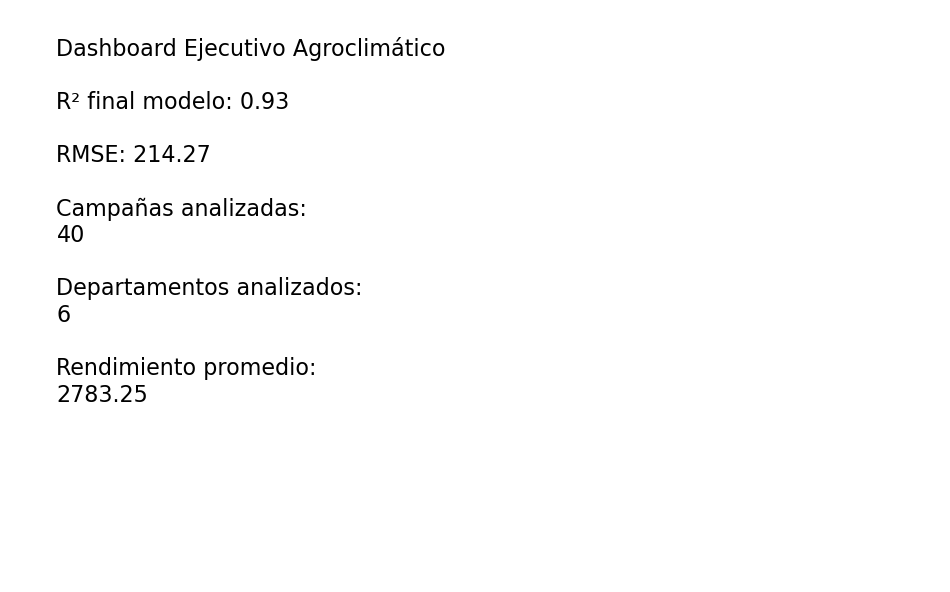

In [4]:
plt.figure(figsize=(12,4))

plt.axis("off")

texto = f"""
Dashboard Ejecutivo Agroclimático

R² final modelo: 0.93

RMSE: 214.27

Campañas analizadas:
{dataset["Campaña"].nunique()}

Departamentos analizados:
{dataset["Departamento"].nunique()}

Rendimiento promedio:
{round(dataset["Rendimiento"].mean(), 2)}
"""

plt.text(
    0.05,
    0.5,
    texto,
    fontsize=16
)

plt.show()

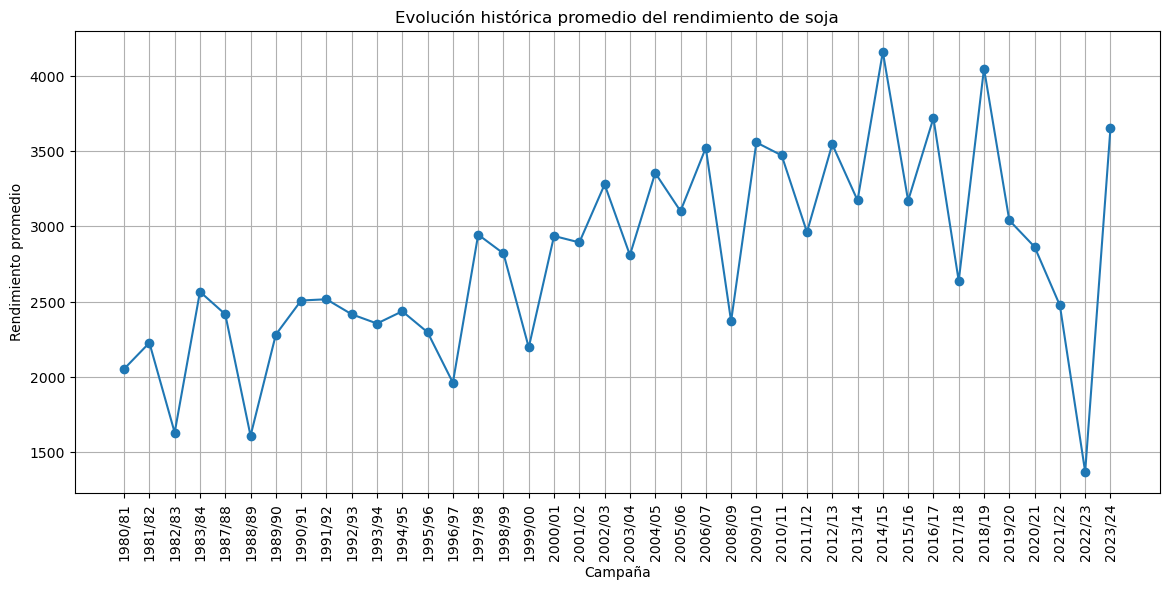

In [5]:
serie_rendimiento = dataset.groupby(
    "Campaña"
)["Rendimiento"].mean().reset_index()

plt.figure(figsize=(14,6))

plt.plot(
    serie_rendimiento["Campaña"],
    serie_rendimiento["Rendimiento"],
    marker="o"
)

plt.title(
    "Evolución histórica promedio del rendimiento de soja"
)

plt.xlabel("Campaña")

plt.ylabel("Rendimiento promedio")

plt.xticks(rotation=90)

plt.grid()

plt.show()

In [7]:
from sklearn.ensemble import RandomForestRegressor

In [8]:
X = dataset[
    [
        "score_suelo_promedio",
        "temp_max_extrema",
        "temp_min_extrema",
        "precipitacion_total",
        "viento_prom",
        "dias_lluvia",
        "humedad_relativa_prom",
        "ENSO_num",
        "VPD_prom"
    ]
]

y = dataset["Rendimiento"]

In [9]:
X = X.apply(
    pd.to_numeric,
    errors="coerce"
)

y = pd.to_numeric(
    y,
    errors="coerce"
)

df_modelo = pd.concat(
    [X, y],
    axis=1
).dropna()

X = df_modelo.drop(
    columns="Rendimiento"
)

y = df_modelo["Rendimiento"]

In [10]:
modelo_rf_vpd = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

modelo_rf_vpd.fit(
    X,
    y
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [11]:
importancias_final = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_rf_vpd.feature_importances_
})

importancias_final = importancias_final.sort_values(
    by="Importancia",
    ascending=False
)

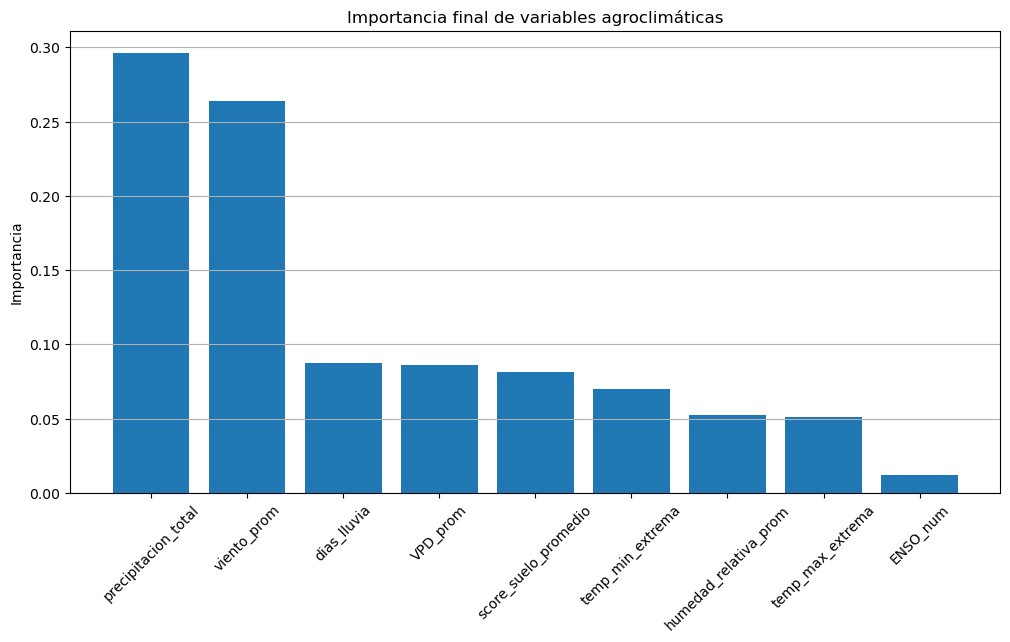

In [12]:
plt.figure(figsize=(12,6))

plt.bar(
    importancias_final["Variable"],
    importancias_final["Importancia"]
)

plt.title(
    "Importancia final de variables agroclimáticas"
)

plt.ylabel("Importancia")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.show()

In [13]:
import matplotlib.patches as mpatches

colores = []

for cat in dataset["categoria_SPEI"]:
    if cat == "Estrés severo":
        colores.append("red")
    elif cat == "Estrés moderado":
        colores.append("orange")
    elif cat == "Muy favorable":
        colores.append("green")
    else:
        colores.append("gray")

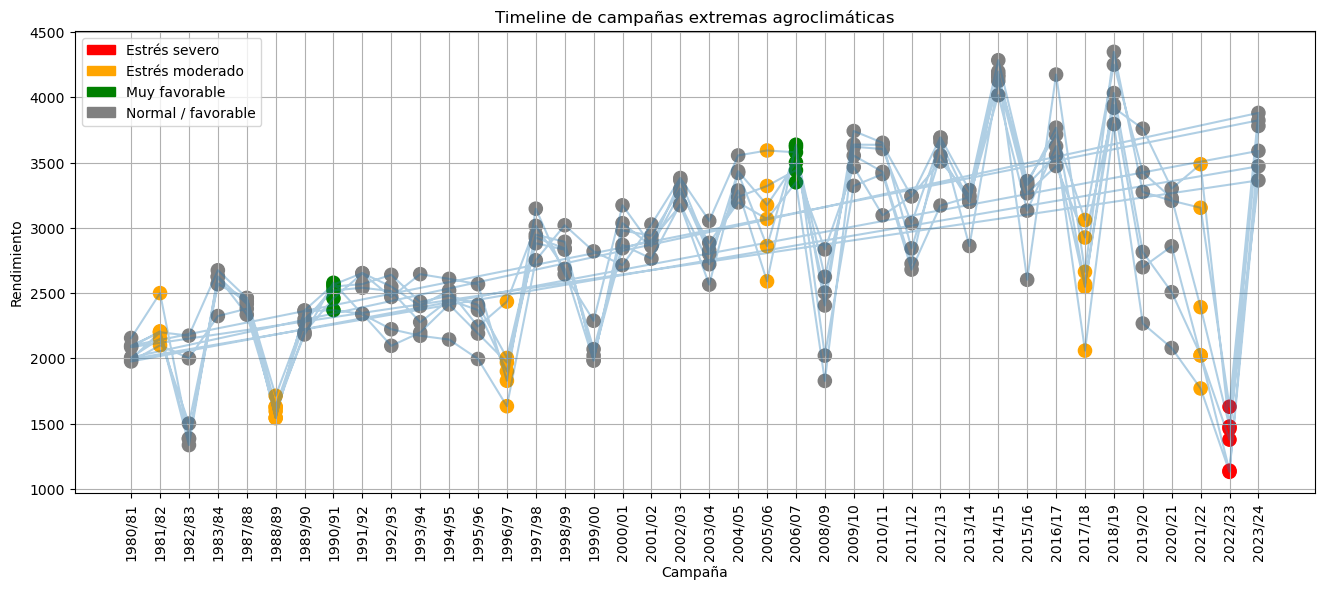

In [14]:
plt.figure(figsize=(16,6))

plt.scatter(
    dataset["Campaña"],
    dataset["Rendimiento"],
    c=colores,
    s=90
)

plt.plot(
    dataset["Campaña"],
    dataset["Rendimiento"],
    alpha=0.35
)

rojo = mpatches.Patch(color="red", label="Estrés severo")
naranja = mpatches.Patch(color="orange", label="Estrés moderado")
verde = mpatches.Patch(color="green", label="Muy favorable")
gris = mpatches.Patch(color="gray", label="Normal / favorable")

plt.legend(handles=[rojo, naranja, verde, gris])

plt.title("Timeline de campañas extremas agroclimáticas")
plt.xlabel("Campaña")
plt.ylabel("Rendimiento")

plt.xticks(rotation=90)
plt.grid()

plt.show()

In [15]:
from sklearn.ensemble import RandomForestRegressor

In [16]:
modelo_final = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

modelo_final.fit(
    X,
    y
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [17]:
pred_total = modelo_final.predict(X)

In [18]:
comparacion = pd.DataFrame({
    "Campaña": dataset.loc[
        df_modelo.index,
        "Campaña"
    ],

    "Real": y.values,

    "Predicho": pred_total
})

comparacion.head()

,Campaña,Real,Predicho
0,1980/81,2156,2119.640000
1,1981/82,2500,2374.936667
2,1982/83,1386,1446.393333
3,1983/84,2574,2535.316667
4,1987/88,2438,2393.696667


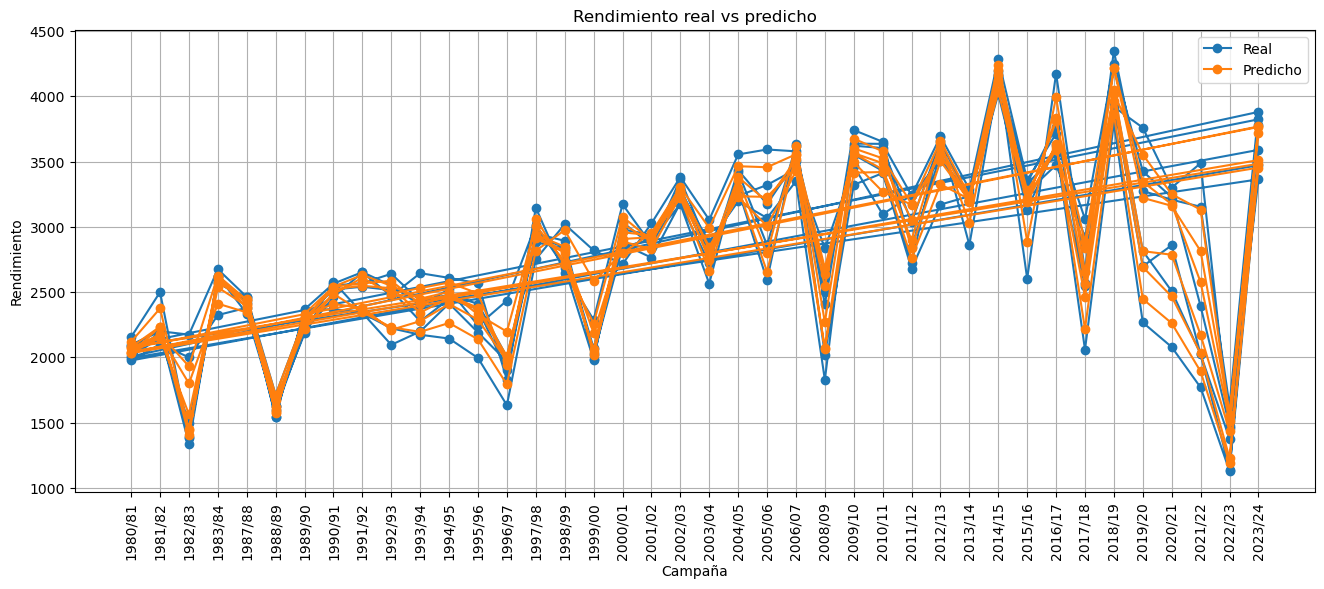

In [19]:
plt.figure(figsize=(16,6))

plt.plot(
    comparacion["Campaña"],
    comparacion["Real"],
    marker="o",
    label="Real"
)

plt.plot(
    comparacion["Campaña"],
    comparacion["Predicho"],
    marker="o",
    label="Predicho"
)

plt.title(
    "Rendimiento real vs predicho"
)

plt.xlabel("Campaña")

plt.ylabel("Rendimiento")

plt.xticks(rotation=90)

plt.legend()

plt.grid()

plt.show()

# Conclusiones del Dashboard Ejecutivo Agroclimático

El dashboard desarrollado resume los principales hallazgos obtenidos durante la construcción del sistema agroclimático predictivo aplicado al rendimiento de soja.

La integración de variables climáticas, atmosféricas, índices de sequía y machine learning permitió representar de forma robusta el comportamiento histórico del sistema agrícola analizado.

---

# Principales hallazgos

Los resultados muestran que el rendimiento agrícola depende principalmente del equilibrio entre:

* disponibilidad hídrica,
* demanda atmosférica,
* humedad relativa,
* y estrés evaporativo.

Las variables más importantes identificadas por el modelo fueron:

* precipitación total,
* viento promedio,
* VPD,
* y días de lluvia.

Estos resultados evidencian que el componente atmosférico posee un rol fundamental dentro de la productividad agrícola.

---

# Índices climáticos

La incorporación de SPI permitió caracterizar campañas secas y húmedas a partir de anomalías de precipitación.

Posteriormente, la incorporación de SPEI permitió representar de forma más robusta las condiciones de estrés hídrico-atmosférico, mostrando una mayor capacidad para identificar campañas críticas con fuertes pérdidas de rendimiento.

---

# Capacidad predictiva del modelo

El modelo Random Forest alcanzó:

* R² ≈ 0.93
* RMSE ≈ 214 kg/ha

Los resultados obtenidos muestran una elevada capacidad predictiva y una fuerte coherencia temporal entre valores reales y predichos.

Asimismo, el sistema logró capturar adecuadamente campañas extremas asociadas a sequías y eventos de estrés agroclimático severo.

---

# Importancia agroclimática

El proyecto demuestra que el rendimiento agrícola no depende únicamente de la precipitación total, sino de la interacción compleja entre:

* clima,
* atmósfera,
* balance hídrico,
* y procesos ecofisiológicos.

La incorporación de variables como humedad relativa, VPD y SPEI permitió mejorar considerablemente la representación del estrés agrícola real.

---

# Conclusión general

El sistema desarrollado constituye una plataforma agroclimática predictiva capaz de integrar información meteorológica, índices climáticos y machine learning para analizar el comportamiento histórico del rendimiento agrícola.

Los resultados obtenidos muestran el potencial de la agroclimatología aplicada y de la ciencia de datos para mejorar la comprensión de los sistemas productivos frente a la variabilidad climática y los eventos extremos.

Este proyecto constituye además una base sólida para la expansión futura hacia modelos multicultivo y sistemas predictivos más avanzados.
